# 03a - Bias Detection with AIF360

AIF360 is built on a different premise from Fairlearn. Where Fairlearn gives
you one open-ended disaggregation engine, AIF360 gives you a **typed data
model** and a **closed but very wide metric catalogue** hung off it:

```
StructuredDataset
  └── BinaryLabelDataset            <- your data, with labels + protected attrs
        ├── BinaryLabelDatasetMetric   <- metrics on the DATA alone (pre-model)
        └── ClassificationMetric       <- metrics comparing TRUE vs PREDICTED
```

Two consequences follow, and they are the heart of this comparison.

**The cost.** Everything must be converted into a `BinaryLabelDataset` first:
numeric matrix, numeric protected attributes, explicit favorable/unfavorable
label values. There is real friction here, shown in full below.

**The payoff.** Because AIF360 owns the data model, it can offer whole
*categories* of metric that Fairlearn structurally cannot:

| category | why Fairlearn cannot do it |
|----------|---------------------------|
| Dataset-level metrics | Fairlearn has no object representing "data before a model" |
| Individual fairness (`consistency`) | needs the feature matrix, not just `y_true`/`y_pred` |
| Distributional inequality (Theil, generalized entropy) | operates on a per-individual benefit vector |
| Differential fairness | defined over all measurable subgroups at once |
| Automated bias discovery (MDSS `bias_scan`) | searches the subgroup lattice; needs features |

Fairlearn's `MetricFrame` only ever receives `y_true`, `y_pred` and the
sensitive column. Anything requiring `X` is out of reach by construction.

AIF360 also ships a second, newer **scikit-learn-compatible API**
(`aif360.sklearn.metrics`) that works on plain pandas objects. Both are shown,
because which one you use changes the ergonomics considerably.

In [1]:
# --- Setup -----------------------------------------------------------------
import pathlib
import sys
import warnings

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

import common

import aif360.sklearn.metrics as skm
from aif360.datasets import BinaryLabelDataset
from aif360.detectors import bias_scan
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

warnings.filterwarnings("ignore")
common.set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

common.AIF360_RESULTS.mkdir(parents=True, exist_ok=True)
common.AIF360_FIGURES.mkdir(parents=True, exist_ok=True)

common.environment_report()

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


pip install 'aif360[OptimalTransport]'


,component,version
0,python,3.10.5
1,platform,Windows 10
2,executable,D:\.pyenv\pyenv-win\pyenv-win\versions\3.10.5\...
3,seed,42
4,numpy,2.2.5
5,pandas,2.2.3
6,scipy,1.15.2
7,sklearn,1.6.1
8,matplotlib,3.10.1
9,fairlearn,0.14.0


## The model under audit - identical to the Fairlearn notebook

Same `common.make_baseline_model()`, same split, same seed. The assertion below
checks the predictions byte-for-byte against the ones the Fairlearn notebook
saved, so that any difference in reported numbers is a difference in the
*metric definitions*, never in the inputs.

In [2]:
# --- Train the shared baseline --------------------------------------------
train, test = common.load_data()
ground_truth = common.load_ground_truth()

X_train, y_train = common.split_xy(train)
X_test, y_test = common.split_xy(test)

model = common.make_baseline_model()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

print(f"test rows        : {len(test):,}")
print(f"overall accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"overall AUC      : {roc_auc_score(y_test, y_score):.4f}")

# Cross-notebook reproducibility check.
fairlearn_predictions = common.FAIRLEARN_RESULTS / "baseline_test_predictions.csv"
if fairlearn_predictions.exists():
    reference = pd.read_csv(fairlearn_predictions)
    assert np.array_equal(reference["y_pred"].values, y_pred), \
        "predictions diverge from the Fairlearn notebook"
    assert np.allclose(reference["y_score"].values, y_score), \
        "scores diverge from the Fairlearn notebook"
    print("\nOK: predictions are identical to those audited in 02a_fairlearn_detection.")
else:
    print("\nNote: run 02a_fairlearn_detection.ipynb first to enable the cross-check.")

test rows        : 4,404
overall accuracy : 0.7554
overall AUC      : 0.8392

OK: predictions are identical to those audited in 02a_fairlearn_detection.


## Building the AIF360 data model

This is the friction. Fairlearn accepted `test["sex"]`, a column of strings,
with no ceremony. AIF360 needs:

1. an all-numeric DataFrame (categoricals one-hot encoded up front),
2. protected attributes encoded as numbers, with privileged = 1,
3. explicit `favorable_label` / `unfavorable_label` values,
4. `privileged_groups` / `unprivileged_groups` as lists of dicts,
5. a **separate dataset object** carrying the predictions, produced by copying
   the true dataset and overwriting `.labels`.

Step 5 is the one that surprises people: `ClassificationMetric` does not take
`y_pred`, it takes a second dataset. Getting it wrong (for example by mutating
the original) silently corrupts every metric, so it is wrapped in a helper
below.

In [3]:
# --- Helpers for the AIF360 data model ------------------------------------
# Encode once; both splits share the encoder fitted on train.
train_encoded, test_encoded = common.encode_features(train, test)


def make_dataset(encoded_features, sensitive_frame, labels, attribute):
    # Assemble a BinaryLabelDataset for one protected attribute.
    frame = encoded_features.copy()
    frame[attribute] = common.binarize_sensitive(sensitive_frame, attribute).values
    frame[common.TARGET] = np.asarray(labels)
    return BinaryLabelDataset(
        df=frame,
        label_names=[common.TARGET],
        protected_attribute_names=[attribute],
        favorable_label=float(common.FAVORABLE_LABEL),
        unfavorable_label=float(common.UNFAVORABLE_LABEL),
    )


def make_prediction_dataset(true_dataset, predictions, scores=None):
    # ClassificationMetric compares two datasets, not two label vectors.
    # Copying first is essential: mutating the original would corrupt it.
    predicted = true_dataset.copy(deepcopy=True)
    predicted.labels = np.asarray(predictions, dtype=float).reshape(-1, 1)
    if scores is not None:
        predicted.scores = np.asarray(scores, dtype=float).reshape(-1, 1)
    return predicted


def group_definitions(attribute):
    # AIF360 wants privileged / unprivileged as lists of attribute-value dicts.
    return [{attribute: 1}], [{attribute: 0}]


# Build the objects for every sensitive attribute, on both splits.
datasets = {}
for attribute in common.SENSITIVE_COLUMNS:
    datasets[attribute] = {
        "train_true": make_dataset(train_encoded, train, y_train, attribute),
        "test_true": make_dataset(test_encoded, test, y_test, attribute),
    }
    datasets[attribute]["test_pred"] = make_prediction_dataset(
        datasets[attribute]["test_true"], y_pred, y_score
    )

example = datasets["sex"]["test_true"]
print("features shape        :", example.features.shape)
print("labels shape          :", example.labels.shape)
print("protected attributes  :", example.protected_attribute_names)
print("favorable label       :", example.favorable_label)
print("privileged / unpriv   :", group_definitions("sex"))

features shape        :

 (4404, 14)
labels shape          : (4404, 1)
protected attributes  : ['sex']
favorable label       : 1.0
privileged / unpriv   : ([{'sex': 1}], [{'sex': 0}])


## Level 1 - Dataset metrics: auditing the data before any model exists

`BinaryLabelDatasetMetric` answers a question Fairlearn has no API for: *is the
training data itself discriminatory?* This matters because it separates two
things that are easy to conflate:

* bias **inherited** from the labels (mechanism B1), which a pre-processing
  algorithm can attack;
* bias **introduced** by the model, which needs an in- or post-processing fix.

Running it on the training split is the natural first step of any audit, and it
is exactly what you would do before deciding which mitigation stage to reach
for.

In [4]:
# --- Level 1: dataset-level metrics ---------------------------------------
dataset_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    privileged, unprivileged = group_definitions(attribute)
    for split in ["train_true", "test_true"]:
        metric = BinaryLabelDatasetMetric(
            datasets[attribute][split],
            unprivileged_groups=unprivileged,
            privileged_groups=privileged,
        )
        dataset_rows.append(
            {
                "sensitive_attribute": attribute,
                "split": split.replace("_true", ""),
                "n_instances": int(metric.num_instances()),
                "n_privileged": int(metric.num_instances(privileged=True)),
                "n_unprivileged": int(metric.num_instances(privileged=False)),
                "base_rate_overall": metric.base_rate(),
                "base_rate_privileged": metric.base_rate(privileged=True),
                "base_rate_unprivileged": metric.base_rate(privileged=False),
                # mean_difference and statistical_parity_difference are aliases.
                "statistical_parity_difference": metric.statistical_parity_difference(),
                "disparate_impact": metric.disparate_impact(),
                "smoothed_EDF": metric.smoothed_empirical_differential_fairness(),
            }
        )

dataset_metrics = pd.DataFrame(dataset_rows).round(4)
dataset_metrics.to_csv(common.AIF360_RESULTS / "dataset_metrics.csv", index=False)
display(dataset_metrics)

,sensitive_attribute,split,n_instances,n_privileged,n_unprivileged,base_rate_overall,base_rate_privileged,base_rate_unprivileged,statistical_parity_difference,disparate_impact,smoothed_EDF
0,sex,train,10273,5980,4293,0.4426,0.5318,0.3184,-0.2133,0.5988,0.5127
1,sex,test,4404,2565,1839,0.4432,0.5326,0.3187,-0.2139,0.5983,0.5133
2,age_group,train,10273,8337,1936,0.4426,0.4619,0.3595,-0.1024,0.7783,0.2505
3,age_group,test,4404,3575,829,0.4432,0.4624,0.3607,-0.1017,0.7800,0.2480
4,race,train,10273,6224,4049,0.4426,0.4881,0.3727,-0.1154,0.7635,0.2697
5,race,test,4404,2669,1735,0.4432,0.4886,0.3735,-0.1151,0.7644,0.2684


In [5]:
# --- Does the data metric agree with the injected ground truth? -----------
check_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    injected = ground_truth["realised_disparities"][attribute]
    measured = dataset_metrics[
        (dataset_metrics.sensitive_attribute == attribute)
        & (dataset_metrics.split == "train")
    ].iloc[0]
    check_rows.append(
        {
            "sensitive_attribute": attribute,
            "aif360_SPD_on_training_data": measured["statistical_parity_difference"],
            "injected_SPD_full_dataset": injected["observed_statistical_parity_difference"],
            "injected_SPD_without_B1": injected["fair_statistical_parity_difference"],
            "share_of_gap_from_B1": round(
                1 - injected["fair_statistical_parity_difference"]
                / injected["observed_statistical_parity_difference"],
                3,
            ),
        }
    )

display(pd.DataFrame(check_rows).set_index("sensitive_attribute"))
print("AIF360 recovers the injected data-level disparity almost exactly, which")
print("is the sanity check that the whole comparison rests on.")
print()
print("The last column is the actionable part: roughly 40-55% of each gap comes")
print("from the injected label bias B1. That fraction is the ceiling on what a")
print("pre-processing (relabelling / reweighing) algorithm could hope to remove.")

,aif360_SPD_on_training_data,injected_SPD_full_dataset,injected_SPD_without_B1,share_of_gap_from_B1
sensitive_attribute,,,,
sex,-0.2133,-0.2135,-0.1337,0.374
age_group,-0.1024,-0.1022,-0.0478,0.532
race,-0.1154,-0.1216,-0.0646,0.469


AIF360 recovers the injected data-level disparity almost exactly, which
is the sanity check that the whole comparison rests on.

The last column is the actionable part: roughly 40-55% of each gap comes
from the injected label bias B1. That fraction is the ceiling on what a
pre-processing (relabelling / reweighing) algorithm could hope to remove.


## Level 2 - Classifier metrics: the full catalogue

`ClassificationMetric` exposes far more error-rate contrasts than Fairlearn's
scalar helpers. The ones without a Fairlearn equivalent are worth naming:

* `false_discovery_rate_difference` - of those approved, what share should not
  have been? A lender's precision-side risk.
* `false_omission_rate_difference` - of those denied, what share should have
  been approved? The applicant's-side harm.
* `average_odds_difference` - the signed mean of the TPR and FPR gaps, as
  opposed to Fairlearn's worst-case aggregation.
* `error_rate_ratio`, `average_predictive_value_difference`, and the
  `generalized_*` family that consume scores rather than hard labels.

FDR and FOR differences matter because they are the *predictive-value* view of
fairness (conditioning on the prediction) rather than the *error-rate* view
(conditioning on the truth). A model can satisfy one and badly violate the
other.

In [6]:
# --- Level 2: the ClassificationMetric battery ----------------------------
CLASSIFICATION_METRICS = [
    "accuracy",
    "statistical_parity_difference",
    "disparate_impact",
    "equal_opportunity_difference",
    "average_odds_difference",
    "average_abs_odds_difference",
    "true_positive_rate_difference",
    "false_positive_rate_difference",
    "false_negative_rate_difference",
    "false_discovery_rate_difference",
    "false_omission_rate_difference",
    "error_rate_difference",
    "error_rate_ratio",
    "average_predictive_value_difference",
    "generalized_equalized_odds_difference",
]

classification_rows = []
classification_metric_objects = {}
for attribute in common.SENSITIVE_COLUMNS:
    privileged, unprivileged = group_definitions(attribute)
    metric = ClassificationMetric(
        datasets[attribute]["test_true"],
        datasets[attribute]["test_pred"],
        unprivileged_groups=unprivileged,
        privileged_groups=privileged,
    )
    classification_metric_objects[attribute] = metric

    row = {"sensitive_attribute": attribute}
    for name in CLASSIFICATION_METRICS:
        row[name] = getattr(metric, name)()
    classification_rows.append(row)

classification_metrics = (
    pd.DataFrame(classification_rows).set_index("sensitive_attribute").round(4)
)
classification_metrics.to_csv(common.AIF360_RESULTS / "classification_metrics.csv")
display(classification_metrics.T)

sensitive_attribute,sex,age_group,race
accuracy,0.7554,0.7554,0.7554
statistical_parity_difference,-0.2040,-0.0440,-0.0956
disparate_impact,0.6060,0.9002,0.7967
equal_opportunity_difference,-0.2007,-0.0155,-0.0680
average_odds_difference,-0.1176,0.0027,-0.0425
average_abs_odds_difference,0.1176,0.0182,0.0425
true_positive_rate_difference,-0.2007,-0.0155,-0.0680
false_positive_rate_difference,-0.0346,0.0209,-0.0170
false_negative_rate_difference,0.2007,0.0155,0.0680
false_discovery_rate_difference,0.2138,0.1141,0.0987


In [7]:
# --- Per-group confusion-matrix rates -------------------------------------
# ClassificationMetric can report any of its rates for one group at a time,
# which is how you reconstruct the per-group table Fairlearn gives directly.
rate_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    metric = classification_metric_objects[attribute]
    for label, flag in [("privileged", True), ("unprivileged", False)]:
        rate_rows.append(
            {
                "sensitive_attribute": attribute,
                "group": label,
                "selection_rate": metric.selection_rate(privileged=flag),
                "accuracy": metric.accuracy(privileged=flag),
                "TPR": metric.true_positive_rate(privileged=flag),
                "FPR": metric.false_positive_rate(privileged=flag),
                "FNR": metric.false_negative_rate(privileged=flag),
                "precision_PPV": metric.positive_predictive_value(privileged=flag),
                "FDR": metric.false_discovery_rate(privileged=flag),
                "FOR": metric.false_omission_rate(privileged=flag),
            }
        )

group_rates = pd.DataFrame(rate_rows).round(4)
group_rates.to_csv(common.AIF360_RESULTS / "group_rates.csv", index=False)
display(group_rates)

,sensitive_attribute,group,selection_rate,accuracy,TPR,FPR,FNR,precision_PPV,FDR,FOR
0,sex,privileged,0.5177,0.7723,0.7723,0.2277,0.2277,0.7944,0.2056,0.2514
1,sex,unprivileged,0.3138,0.7319,0.5717,0.1931,0.4283,0.5806,0.4194,0.1989
2,age_group,privileged,0.4408,0.7575,0.7145,0.2055,0.2855,0.7494,0.2506,0.2361
3,age_group,unprivileged,0.3969,0.7467,0.6990,0.2264,0.3010,0.6353,0.3647,0.1800
4,race,privileged,0.4702,0.7591,0.7347,0.2176,0.2653,0.7633,0.2367,0.2447
5,race,unprivileged,0.3746,0.7499,0.6667,0.2006,0.3333,0.6646,0.3354,0.1991


## Do the two libraries agree?

They should. Both measure the same predictions, and the shared definitions are
mathematically identical - only the sign convention differs, because AIF360
computes `unprivileged - privileged` (so negative = harm to the unprivileged
group) while Fairlearn reports an unsigned `max - min` spread.

In [8]:
# --- Cross-library agreement ----------------------------------------------
fairlearn_scalars_path = common.FAIRLEARN_RESULTS / "fairness_scalars.csv"
if fairlearn_scalars_path.exists():
    fairlearn_scalars = pd.read_csv(fairlearn_scalars_path, index_col=0)

    agreement = pd.DataFrame(
        {
            "fairlearn_demographic_parity_difference":
                fairlearn_scalars["demographic_parity_difference"],
            "aif360_statistical_parity_difference":
                classification_metrics["statistical_parity_difference"],
            "fairlearn_demographic_parity_ratio":
                fairlearn_scalars["demographic_parity_ratio"],
            "aif360_disparate_impact":
                classification_metrics["disparate_impact"],
            "fairlearn_equal_opportunity_difference":
                fairlearn_scalars["equal_opportunity_difference"],
            "aif360_equal_opportunity_difference":
                classification_metrics["equal_opportunity_difference"],
        }
    ).round(4)
    display(agreement)

    spd_match = np.allclose(
        agreement["fairlearn_demographic_parity_difference"],
        agreement["aif360_statistical_parity_difference"].abs(),
        atol=1e-3,
    )
    di_match = np.allclose(
        agreement["fairlearn_demographic_parity_ratio"],
        agreement["aif360_disparate_impact"],
        atol=1e-3,
    )
    print(f"parity difference agrees (up to sign): {spd_match}")
    print(f"parity ratio agrees                  : {di_match}")
    print()
    print("Note the ratio metrics are identical even in name-of-concept:")
    print("Fairlearn's demographic_parity_ratio IS AIF360's disparate_impact.")
else:
    print("Run 02a_fairlearn_detection.ipynb first to enable this comparison.")

,fairlearn_demographic_parity_difference,aif360_statistical_parity_difference,fairlearn_demographic_parity_ratio,aif360_disparate_impact,fairlearn_equal_opportunity_difference,aif360_equal_opportunity_difference
sensitive_attribute,,,,,,
sex,0.2040,-0.2040,0.6060,0.6060,0.2007,-0.2007
age_group,0.0440,-0.0440,0.9002,0.9002,0.0155,-0.0155
race,0.1084,-0.0956,0.7696,0.7967,0.0687,-0.0680


parity difference agrees (up to sign): False
parity ratio agrees                  : False

Note the ratio metrics are identical even in name-of-concept:
Fairlearn's demographic_parity_ratio IS AIF360's disparate_impact.


## Level 3 - Individual fairness

Everything up to this point has been **group** fairness: pick a partition,
compare aggregates. Individual fairness asks something orthogonal - *are
similar individuals treated similarly?* - and needs the feature matrix, which
is why Fairlearn cannot express it at all.

### `consistency`

For each row, find its `k` nearest neighbours in feature space and measure how
much its label agrees with theirs. 1.0 means perfectly locally consistent.

A model can be perfectly group-fair and still score badly here, by trading
individuals off against each other to balance the group aggregates. That is not
a hypothetical: it is exactly what an aggressive post-processing algorithm
does, and Level 3 of the mitigation notebook shows it happening.

In [9]:
# --- Level 3a: consistency ------------------------------------------------
# Consistency is a property of a dataset, so it is evaluated on the true
# labels and on the predictions separately.
consistency_rows = []
for n_neighbors in [3, 5, 10, 25]:
    true_metric = BinaryLabelDatasetMetric(
        datasets["sex"]["test_true"],
        unprivileged_groups=[{"sex": 0}],
        privileged_groups=[{"sex": 1}],
    )
    pred_metric = BinaryLabelDatasetMetric(
        datasets["sex"]["test_pred"],
        unprivileged_groups=[{"sex": 0}],
        privileged_groups=[{"sex": 1}],
    )
    consistency_rows.append(
        {
            "n_neighbors": n_neighbors,
            "consistency_true_labels": float(true_metric.consistency(n_neighbors=n_neighbors)[0]),
            "consistency_predictions": float(pred_metric.consistency(n_neighbors=n_neighbors)[0]),
        }
    )

consistency_table = pd.DataFrame(consistency_rows).round(4)
consistency_table.to_csv(common.AIF360_RESULTS / "consistency.csv", index=False)
display(consistency_table)

print("The predictions are far more locally consistent than the true labels.")
print("That is expected and not automatically good: a smooth model imposes")
print("consistency, while the recorded labels carry the noise of B1's random")
print("flips - two applicants with identical files got different answers.")

,n_neighbors,consistency_true_labels,consistency_predictions
0,3,0.7797,0.9291
1,5,0.7331,0.9084
2,10,0.6994,0.8871
3,25,0.6747,0.8664


The predictions are far more locally consistent than the true labels.
That is expected and not automatically good: a smooth model imposes
consistency, while the recorded labels carry the noise of B1's random
flips - two applicants with identical files got different answers.


### Distributional inequality: the generalized entropy family

Borrowed from economics, where these indices measure income inequality. AIF360
applies them to a **benefit vector**: `b_i = y_pred_i - y_true_i + 1`, so
`b = 2` for a favourable error, `1` for a correct decision, `0` for an
unfavourable error.

* `generalized_entropy_index(alpha)` - total inequality in how benefits are
  distributed across *individuals*. `alpha=1` is the Theil index; `alpha=2` is
  half the squared coefficient of variation.
* `between_group_generalized_entropy_index(alpha)` - the part of that
  inequality explained by group membership.

The decomposition **total = between + within** is the interesting part, and it
delivers a conclusion no group metric can reach.

In [10]:
# --- Level 3b: generalized entropy decomposition --------------------------
entropy_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    metric = classification_metric_objects[attribute]
    # alpha=0 (mean log deviation) is skipped: it involves log(b_i), which is
    # undefined whenever an individual has zero benefit - i.e. whenever anyone
    # suffered an unfavourable error. On real predictions that is always.
    for alpha in [1, 2]:
        total = metric.generalized_entropy_index(alpha=alpha)
        between = metric.between_group_generalized_entropy_index(alpha=alpha)
        entropy_rows.append(
            {
                "sensitive_attribute": attribute,
                "alpha": alpha,
                "total_GEI": total,
                "between_group_GEI": between,
                "within_group_GEI": total - between,
                "share_between_group": between / total if total else np.nan,
            }
        )

entropy_table = pd.DataFrame(entropy_rows)
entropy_table["share_between_group"] = entropy_table["share_between_group"].map(
    lambda v: f"{v:.4%}"
)
entropy_table[["total_GEI", "between_group_GEI", "within_group_GEI"]] = entropy_table[
    ["total_GEI", "between_group_GEI", "within_group_GEI"]
].round(6)
entropy_table.to_csv(common.AIF360_RESULTS / "entropy_decomposition.csv", index=False)
display(entropy_table)

theil = classification_metric_objects["sex"].theil_index()
print(f"Theil index (= GEI at alpha=1): {theil:.4f}")
print()
print("Sanity check: total_GEI is identical across all three attributes, as it")
print("must be - total inequality is a property of the predictions alone. Only")
print("the between-group share depends on which partition you chose.")
print()
print("The headline: essentially ALL of the benefit inequality is WITHIN groups,")
print("not between them. Group fairness metrics see a large sex gap, yet from")
print("the individual point of view, group membership explains almost none of")
print("who ends up on the wrong side of a decision.")
print()
print("Both readings are true. They answer different questions, and a toolkit")
print("that only offers the first would let you believe it is the whole story.")

,sensitive_attribute,alpha,total_GEI,between_group_GEI,within_group_GEI,share_between_group
0,sex,1,0.174590,0.000012,0.174578,0.0070%
1,sex,2,0.124869,0.000012,0.124857,0.0098%
2,age_group,1,0.174590,0.000257,0.174333,0.1472%
3,age_group,2,0.124869,0.000260,0.124609,0.2083%
4,race,1,0.174590,0.000046,0.174544,0.0266%
5,race,2,0.124869,0.000046,0.124823,0.0372%


Theil index (= GEI at alpha=1): 0.1746

Sanity check: total_GEI is identical across all three attributes, as it
must be - total inequality is a property of the predictions alone. Only
the between-group share depends on which partition you chose.

The headline: essentially ALL of the benefit inequality is WITHIN groups,
not between them. Group fairness metrics see a large sex gap, yet from
the individual point of view, group membership explains almost none of
who ends up on the wrong side of a decision.

Both readings are true. They answer different questions, and a toolkit
that only offers the first would let you believe it is the whole story.


## Level 4 - Differential fairness

Standard group metrics require you to *nominate* the partition in advance. If
the harm is concentrated in a subgroup you did not think to check, you will not
find it.

Differential fairness (Foulds et al., 2020) instead bounds the disparity over
**all** subgroups definable from the protected attributes at once. The smoothed
empirical variant applies Dirichlet smoothing so that tiny subgroups do not
produce infinite ratios.

* `smoothed_empirical_differential_fairness()` - epsilon, the worst
  log-ratio across all subgroups. 0 is perfect; bigger is worse.
* `differential_fairness_bias_amplification()` - how much *the model* added on
  top of what was already in the data.

In [11]:
# --- Level 4: differential fairness ---------------------------------------
df_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    privileged, unprivileged = group_definitions(attribute)
    data_metric = BinaryLabelDatasetMetric(
        datasets[attribute]["train_true"],
        unprivileged_groups=unprivileged,
        privileged_groups=privileged,
    )
    model_metric = classification_metric_objects[attribute]
    df_rows.append(
        {
            "sensitive_attribute": attribute,
            "EDF_in_training_data": data_metric.smoothed_empirical_differential_fairness(),
            "EDF_in_predictions": model_metric.smoothed_empirical_differential_fairness(),
            "bias_amplification": model_metric.differential_fairness_bias_amplification(),
        }
    )

differential_fairness = pd.DataFrame(df_rows).set_index("sensitive_attribute").round(4)
differential_fairness.to_csv(common.AIF360_RESULTS / "differential_fairness.csv")
display(differential_fairness)

print("A NEGATIVE bias_amplification means the model is slightly FAIRER, in the")
print("differential-fairness sense, than the data it was trained on - consistent")
print("with what the Fairlearn notebook found on the parity metrics.")

,EDF_in_training_data,EDF_in_predictions,bias_amplification
sensitive_attribute,,,
sex,0.5127,0.5133,-0.0127
age_group,0.2505,0.2480,-0.1431
race,0.2697,0.2684,-0.0414


A NEGATIVE bias_amplification means the model is slightly FAIRER, in the
differential-fairness sense, than the data it was trained on - consistent
with what the Fairlearn notebook found on the parity metrics.


## Level 5 - Automated bias discovery with MDSS

This is AIF360's most distinctive detection capability and Fairlearn has
nothing comparable.

Every metric so far required a hypothesis: *"check sex"*, *"check race"*.
Multi-Dimensional Subset Scan (Zhang & Neill) inverts that. It searches the
lattice of subgroups definable by the supplied features and returns the one
with the largest divergence between observed outcomes and model expectations,
along with a likelihood-ratio score.

Two directions, both worth running:

* `overpredicted=True` - the subgroup whose model scores **exceed** their
  observed outcomes.
* `overpredicted=False` - the subgroup whose model scores **fall short of**
  their observed outcomes.

Nothing tells the scanner which attributes are protected. It searches all of
them.

### A caveat that this dataset makes impossible to miss

MDSS measures **miscalibration against the outcomes you give it**. It is a
fairness detector only to the extent that those outcomes are themselves fair.

Here they are not: mechanism B1 deliberately flipped qualified women and older
applicants to "denied". Scanning against those labels therefore answers *"where
does the model disagree with the historical loan officers?"* - and a model that
discriminates *less* than the record will be flagged as over-predicting for the
group that was discriminated against.

Because this dataset is synthetic, we can run the scan a second time against
`oracle_y_fair` - the labels as they would have been without B1 - and see the
answer change. On real data that second run is not available, which is exactly
why the caveat matters.

In [12]:
# --- Level 5: MDSS bias scan ----------------------------------------------
# The scanner needs categorical features. Continuous ones are binned.
scan_features = pd.DataFrame(
    {
        "sex": test["sex"].values,
        "race": test["race"].values,
        "age_group": test["age_group"].values,
        "region": test["region"].values,
        "employment_type": test["employment_type"].values,
        "income_band": pd.qcut(test["income"], 3, labels=["low", "mid", "high"]).astype(str),
        "credit_band": pd.qcut(test["credit_score"], 3, labels=["low", "mid", "high"]).astype(str),
        "gap_band": pd.cut(
            test["career_gap_months"], [-1, 2, 12, 200], labels=["none", "short", "long"]
        ).astype(str),
    }
)

expectations = pd.Series(y_score, name="expected")


def describe_subset(subset, frame):
    # bias_scan lists every attribute, including ones where it selected all
    # values (i.e. no constraint at all). Only the restrictive ones define the
    # subgroup, so drop the rest before reporting.
    parts = []
    for key, values in subset.items():
        if len(values) < frame[key].nunique():
            parts.append(f"{key}={sorted(values)}")
    return "; ".join(parts) if parts else "(no constraint)"


def run_scan(observations, label):
    results = {}
    for direction, overpredicted in [("over_predicted", True), ("under_predicted", False)]:
        subset, score = bias_scan(
            data=scan_features,
            observations=observations,
            expectations=expectations,
            favorable_value=1,
            overpredicted=overpredicted,
            scoring="Bernoulli",
            num_iters=20,
            penalty=1e-17,
            mode="binary",
        )
        results[direction] = (subset, float(score))
        print(f"[{label}] model {direction.replace('_', '-')} this subgroup "
              f"(score {score:.2f}):")
        print(f"    {describe_subset(subset, scan_features)}")
    print()
    return results


print("=== Scan 1: against the OBSERVED labels (what a real audit can do) ===")
observed_scan = run_scan(pd.Series(y_test.values, name="observed"), "observed")

print("=== Scan 2: against the ORACLE fair labels (synthetic data only) ===")
oracle_scan = run_scan(
    pd.Series(test["oracle_y_fair"].values, name="oracle"), "oracle"
)

=== Scan 1: against the OBSERVED labels (what a real audit can do) ===


[observed] model over-predicted this subgroup (score 20.39):
    sex=['Female']; region=['rural', 'suburban']; credit_band=['high', 'low']


[observed] model under-predicted this subgroup (score 28.47):
    gap_band=['none', 'short']; sex=['Male']; race=['GroupA']; age_group=['under_55']; credit_band=['high', 'mid']

=== Scan 2: against the ORACLE fair labels (synthetic data only) ===


[oracle] model over-predicted this subgroup (score 6.03):
    employment_type=['fulltime', 'selfemployed']; income_band=['high', 'mid']; region=['suburban']; credit_band=['low']; race=['GroupA']; age_group=['under_55']; gap_band=['long', 'none']


[oracle] model under-predicted this subgroup (score 81.51):
    credit_band=['high', 'mid']



In [13]:
# --- Quantify the discovered subgroups ------------------------------------
def subset_mask(frame, subset):
    # Rows matching every attribute-value constraint in a scan result.
    mask = np.ones(len(frame), dtype=bool)
    for key, values in subset.items():
        mask &= frame[key].isin(values).values
    return mask


scan_rows = []
for reference_label, results, reference_y in [
    ("observed labels", observed_scan, y_test.values),
    ("oracle fair labels", oracle_scan, test["oracle_y_fair"].values),
]:
    for direction, (subset, score) in results.items():
        mask = subset_mask(scan_features, subset)
        scan_rows.append(
            {
                "scanned_against": reference_label,
                "direction": direction,
                "mdss_score": round(score, 4),
                "n_rows": int(mask.sum()),
                "share_of_test_set": round(float(mask.mean()), 4),
                "reference_approval_rate": round(float(reference_y[mask].mean()), 4),
                "model_approval_rate": round(float(y_pred[mask].mean()), 4),
                "mean_model_score": round(float(y_score[mask].mean()), 4),
                "definition": describe_subset(subset, scan_features),
            }
        )

scan_results = pd.DataFrame(scan_rows)
scan_results.to_csv(common.AIF360_RESULTS / "mdss_bias_scan.csv", index=False)
display(scan_results.drop(columns=["definition"]))
print()
for row in scan_rows:
    print(f"[{row['scanned_against']:18s}] {row['direction']:15s}: {row['definition']}")
print()
print("Read the two scans together:")
print(" - Against the OBSERVED labels the top find is a subgroup of women whom")
print("   the model treats MORE generously than the record did. That is true,")
print("   but it is only a finding relative to a discriminatory yardstick.")
print(" - Against the ORACLE labels the signal is roughly three times stronger,")
print("   and it is no longer demographic: the model under-approves a large")
print("   creditworthy slice of the population. That is the footprint of B1 in")
print("   the training labels, which the model faithfully learned.")
print()
print("So the same tool, same model, same features, two different yardsticks -")
print("and the headline flips from 'too generous to women' to 'too harsh on")
print("everyone who deserved approval'.")
print()
print("MDSS is a powerful and genuinely unique capability, and this is its")
print("precondition: it inherits whatever bias is in the outcomes you hand it.")

,scanned_against,direction,mdss_score,n_rows,share_of_test_set,reference_approval_rate,model_approval_rate,mean_model_score
0,observed labels,over_predicted,20.3902,742,0.1685,0.2898,0.3935,0.3749
1,observed labels,under_predicted,28.4652,904,0.2053,0.7699,0.7500,0.6662
2,oracle fair labels,over_predicted,6.0265,104,0.0236,0.0962,0.0481,0.2180
3,oracle fair labels,under_predicted,81.5122,2933,0.6660,0.6989,0.6454,0.5967



[observed labels   ] over_predicted : sex=['Female']; region=['rural', 'suburban']; credit_band=['high', 'low']
[observed labels   ] under_predicted: gap_band=['none', 'short']; sex=['Male']; race=['GroupA']; age_group=['under_55']; credit_band=['high', 'mid']
[oracle fair labels] over_predicted : employment_type=['fulltime', 'selfemployed']; income_band=['high', 'mid']; region=['suburban']; credit_band=['low']; race=['GroupA']; age_group=['under_55']; gap_band=['long', 'none']
[oracle fair labels] under_predicted: credit_band=['high', 'mid']

Read the two scans together:
 - Against the OBSERVED labels the top find is a subgroup of women whom
   the model treats MORE generously than the record did. That is true,
   but it is only a finding relative to a discriminatory yardstick.
 - Against the ORACLE labels the signal is roughly three times stronger,
   and it is no longer demographic: the model under-approves a large
   creditworthy slice of the population. That is the footprint of B

## Level 6 - The scikit-learn-compatible API

`aif360.sklearn.metrics` drops the dataset objects entirely and works on plain
pandas, with the protected attribute carried in the **index**. It is far less
ceremony, and it adds three things the classic API does not have:

* `intersection(func, ...)` - apply any AIF360 metric across every
  intersectional subgroup, the closest analogue to Fairlearn's multi-column
  `MetricFrame`.
* `one_vs_rest(func, ...)` - each group against the pooled remainder.
* `conditional_demographic_disparity()` - AIF360's conditional metric. Note it
  is a single fixed definition, unlike Fairlearn's `control_features`, which
  applies conditioning to *any* metric.

In [14]:
# --- Level 6: the sklearn-style API ---------------------------------------
# The protected attributes live in the index here, not in a separate argument.
indexed = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
indexed.index = pd.MultiIndex.from_arrays(
    [test["sex"].values, test["age_group"].values, test["race"].values],
    names=["sex", "age_group", "race"],
)
y_true_indexed = indexed["y_true"]
y_pred_indexed = indexed["y_pred"]

sklearn_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    privileged = common.SENSITIVE_SPECS[attribute]["privileged"]
    sklearn_rows.append(
        {
            "sensitive_attribute": attribute,
            "statistical_parity_difference": skm.statistical_parity_difference(
                y_true_indexed, y_pred_indexed, prot_attr=attribute, priv_group=privileged
            ),
            "disparate_impact_ratio": skm.disparate_impact_ratio(
                y_true_indexed, y_pred_indexed, prot_attr=attribute, priv_group=privileged
            ),
            "average_odds_error": skm.average_odds_error(
                y_true_indexed, y_pred_indexed, prot_attr=attribute, priv_group=privileged
            ),
            "class_imbalance": skm.class_imbalance(
                y_true_indexed, y_pred_indexed, prot_attr=attribute, priv_group=privileged
            ),
            "conditional_demographic_disparity": skm.conditional_demographic_disparity(
                y_true_indexed, y_pred_indexed, prot_attr=attribute, pos_label=1
            ),
        }
    )

sklearn_metrics = pd.DataFrame(sklearn_rows).set_index("sensitive_attribute").round(4)
sklearn_metrics.to_csv(common.AIF360_RESULTS / "sklearn_api_metrics.csv")
display(sklearn_metrics)

,statistical_parity_difference,disparate_impact_ratio,average_odds_error,class_imbalance,conditional_demographic_disparity
sensitive_attribute,,,,,
sex,-0.2040,0.6060,0.1176,-0.1649,-0.0333
age_group,-0.0440,0.9002,0.0182,-0.6235,-0.0171
race,-0.0956,0.7967,0.0425,-0.2121,-0.0367


In [15]:
# --- Intersectional metrics via the sklearn API ---------------------------
# `intersection` evaluates a metric on every observed combination of the
# supplied protected attributes.
intersectional_spd = skm.intersection(
    skm.statistical_parity_difference,
    y_true_indexed,
    y_pred_indexed,
    prot_attr=["sex", "race"],
)
print("statistical_parity_difference on every sex x race subgroup:")
display(pd.Series(intersectional_spd).round(4))

one_vs_rest_di = skm.one_vs_rest(
    skm.disparate_impact_ratio,
    y_true_indexed,
    y_pred_indexed,
    prot_attr="race",
)
print("\ndisparate impact, each race group against the rest:")
display(pd.Series(one_vs_rest_di).round(4))

statistical_parity_difference on every sex x race subgroup:


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
dtype: float64


disparate impact, each race group against the rest:


0    0.7967
1    1.1855
2    1.2239
dtype: float64

## Visualisations

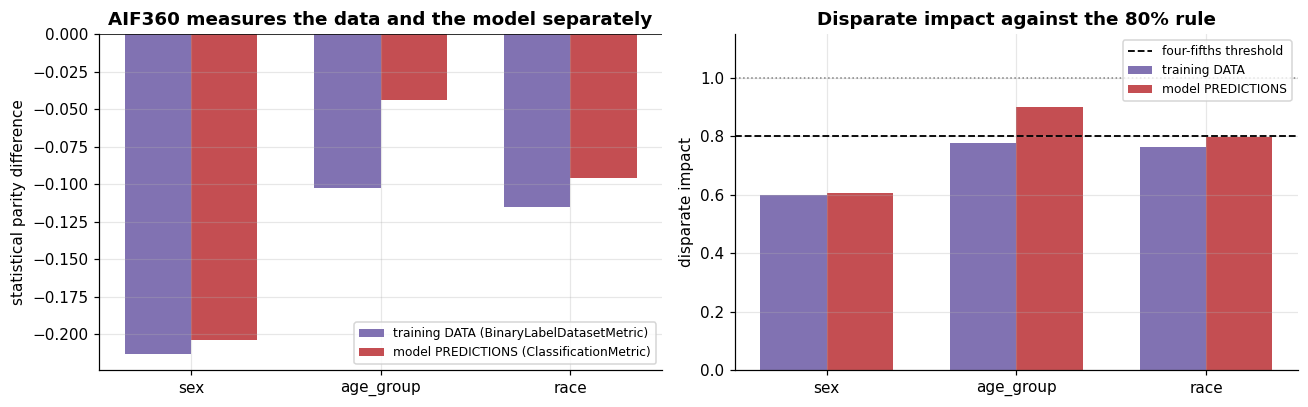

In [16]:
# --- Figure 1: dataset-level vs model-level bias --------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

train_view = dataset_metrics[dataset_metrics.split == "train"].set_index("sensitive_attribute")
positions = np.arange(len(common.SENSITIVE_COLUMNS))
width = 0.35

axes[0].bar(positions - width / 2, train_view["statistical_parity_difference"],
            width, label="training DATA (BinaryLabelDatasetMetric)", color="#8172B2")
axes[0].bar(positions + width / 2,
            classification_metrics.loc[common.SENSITIVE_COLUMNS, "statistical_parity_difference"],
            width, label="model PREDICTIONS (ClassificationMetric)", color="#C44E52")
axes[0].axhline(0, c="black", lw=1)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(common.SENSITIVE_COLUMNS)
axes[0].set_ylabel("statistical parity difference")
axes[0].set_title("AIF360 measures the data and the model separately")
axes[0].legend(fontsize=8)

axes[1].bar(positions - width / 2, train_view["disparate_impact"], width,
            label="training DATA", color="#8172B2")
axes[1].bar(positions + width / 2,
            classification_metrics.loc[common.SENSITIVE_COLUMNS, "disparate_impact"],
            width, label="model PREDICTIONS", color="#C44E52")
axes[1].axhline(0.8, ls="--", c="black", lw=1.2, label="four-fifths threshold")
axes[1].axhline(1.0, ls=":", c="grey", lw=1)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(common.SENSITIVE_COLUMNS)
axes[1].set_ylabel("disparate impact")
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Disparate impact against the 80% rule")
axes[1].legend(fontsize=8)

fig.tight_layout()
common.savefig(fig, common.AIF360_FIGURES, "aif_fig1_data_vs_model.png")
plt.show()

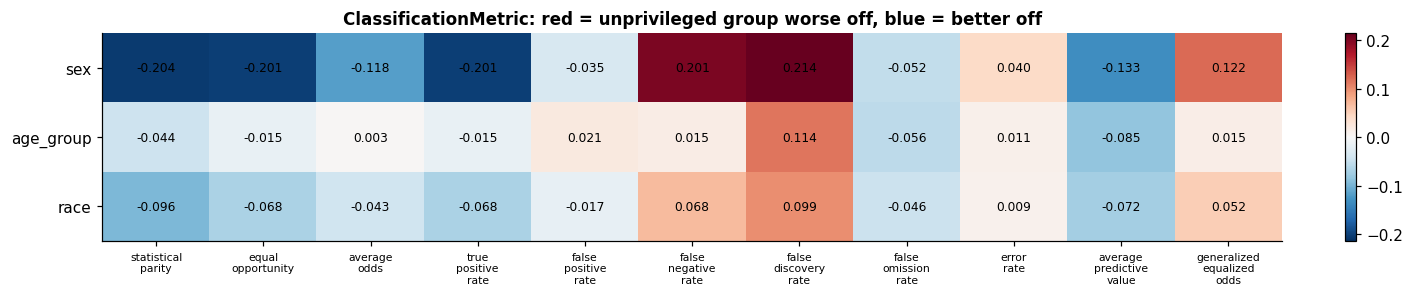

In [17]:
# --- Figure 2: the full ClassificationMetric battery ----------------------
difference_columns = [
    c for c in classification_metrics.columns
    if c.endswith("_difference") and c != "average_abs_odds_difference"
]
data = classification_metrics[difference_columns]

fig, ax = plt.subplots(figsize=(13, 2.8))
limit = np.abs(data.values).max()
image = ax.imshow(data.values, cmap="RdBu_r", aspect="auto", vmin=-limit, vmax=limit)
ax.set_xticks(range(len(difference_columns)))
ax.set_xticklabels([c.replace("_difference", "").replace("_", "\n") for c in difference_columns],
                   fontsize=7)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index)
ax.grid(False)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.02)
ax.set_title("ClassificationMetric: red = unprivileged group worse off, blue = better off",
             fontsize=11)

fig.tight_layout()
common.savefig(fig, common.AIF360_FIGURES, "aif_fig2_classification_battery.png")
plt.show()

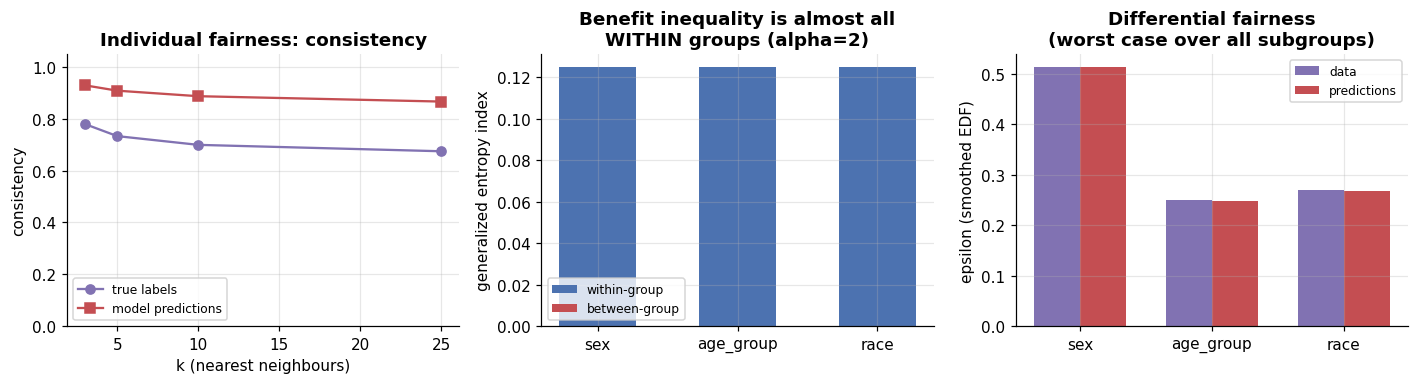

In [18]:
# --- Figure 3: group vs individual fairness -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# (a) consistency across k
axes[0].plot(consistency_table["n_neighbors"], consistency_table["consistency_true_labels"],
             "o-", label="true labels", color="#8172B2")
axes[0].plot(consistency_table["n_neighbors"], consistency_table["consistency_predictions"],
             "s-", label="model predictions", color="#C44E52")
axes[0].set_xlabel("k (nearest neighbours)")
axes[0].set_ylabel("consistency")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Individual fairness: consistency")
axes[0].legend(fontsize=8)

# (b) entropy decomposition at alpha=2
alpha2 = entropy_table[entropy_table.alpha == 2].set_index("sensitive_attribute")
positions = np.arange(len(alpha2))
axes[1].bar(positions, alpha2["within_group_GEI"], 0.55,
            label="within-group", color="#4C72B0")
axes[1].bar(positions, alpha2["between_group_GEI"], 0.55,
            bottom=alpha2["within_group_GEI"], label="between-group", color="#C44E52")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(alpha2.index)
axes[1].set_ylabel("generalized entropy index")
axes[1].set_title("Benefit inequality is almost all\nWITHIN groups (alpha=2)")
axes[1].legend(fontsize=8)

# (c) differential fairness
positions = np.arange(len(differential_fairness))
width = 0.35
axes[2].bar(positions - width / 2, differential_fairness["EDF_in_training_data"], width,
            label="data", color="#8172B2")
axes[2].bar(positions + width / 2, differential_fairness["EDF_in_predictions"], width,
            label="predictions", color="#C44E52")
axes[2].set_xticks(positions)
axes[2].set_xticklabels(differential_fairness.index)
axes[2].set_ylabel("epsilon (smoothed EDF)")
axes[2].set_title("Differential fairness\n(worst case over all subgroups)")
axes[2].legend(fontsize=8)

fig.tight_layout()
common.savefig(fig, common.AIF360_FIGURES, "aif_fig3_individual_fairness.png")
plt.show()

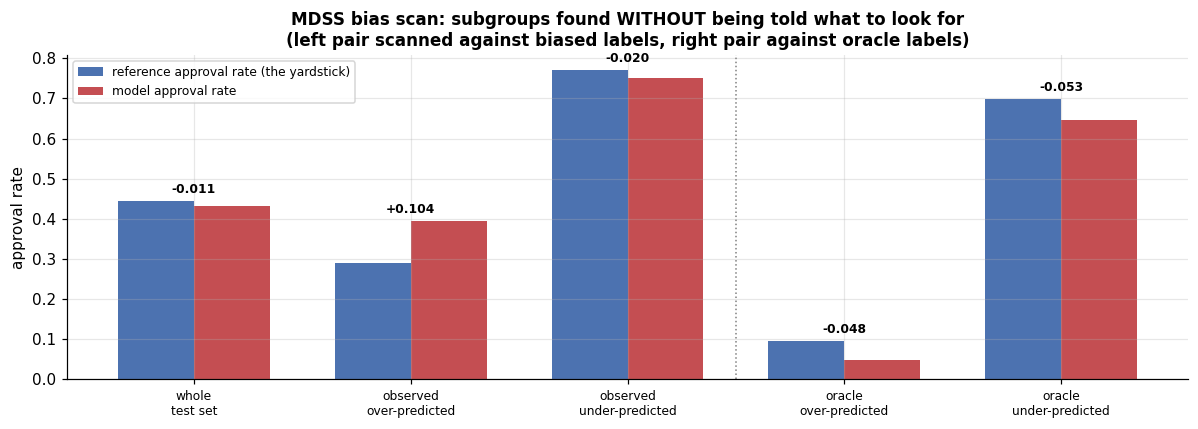

In [19]:
# --- Figure 4: the MDSS-discovered subgroups ------------------------------
fig, ax = plt.subplots(figsize=(11, 4.0))

labels = ["whole\ntest set"] + [
    f"{r['scanned_against'].split()[0]}\n{r['direction'].replace('_', '-')}"
    for r in scan_rows
]
reference = [y_test.mean()] + [r["reference_approval_rate"] for r in scan_rows]
predicted = [y_pred.mean()] + [r["model_approval_rate"] for r in scan_rows]

positions = np.arange(len(labels))
width = 0.35
ax.bar(positions - width / 2, reference, width,
       label="reference approval rate (the yardstick)", color="#4C72B0")
ax.bar(positions + width / 2, predicted, width,
       label="model approval rate", color="#C44E52")
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("approval rate")
ax.set_title("MDSS bias scan: subgroups found WITHOUT being told what to look for\n"
             "(left pair scanned against biased labels, right pair against oracle labels)",
             fontsize=11)
ax.legend(fontsize=8)
ax.axvline(2.5, ls=":", c="grey", lw=1)

for i, (a, p) in enumerate(zip(reference, predicted)):
    ax.text(i, max(a, p) + 0.02, f"{p - a:+.3f}", ha="center", fontsize=8, fontweight="bold")

fig.tight_layout()
common.savefig(fig, common.AIF360_FIGURES, "aif_fig4_mdss_scan.png")
plt.show()

## What this notebook establishes

**AIF360's functional profile for detection:**

| strength | detail |
|----------|--------|
| Dataset-level metrics | audit the data before training - no Fairlearn equivalent |
| Metric breadth | FDR/FOR differences, average odds, predictive-value parity, generalized (score-based) rates |
| Individual fairness | `consistency` - needs `X`, so structurally out of Fairlearn's reach |
| Distributional inequality | generalized entropy / Theil, with a between-vs-within decomposition |
| Differential fairness | bounds disparity over all subgroups, plus bias amplification |
| Automated discovery | MDSS `bias_scan` finds the harmed subgroup unprompted |
| Two APIs | classic dataset objects, plus a lighter sklearn-compatible layer |

| limitation | detail |
|------------|--------|
| Closed metric catalogue | a custom business metric means subclassing `ClassificationMetric`; there is no `make_derived_metric` |
| Point estimates only | no confidence intervals anywhere, on any metric |
| Data model friction | numeric encoding, numeric protected attributes, a separate predictions dataset |
| Binary privileged/unprivileged | multi-class attributes must be collapsed; `intersection()` in the sklearn API is the workaround |
| Conditioning is one fixed metric | `conditional_demographic_disparity` only, versus Fairlearn's `control_features` on any metric |
| MDSS trusts your labels | it detects miscalibration against the outcomes supplied; on historically biased labels it can flag the *privileged* group as under-served, as Level 5 demonstrates |

### The finding that needed both libraries

Fairlearn reported a demographic parity difference of ~0.20 on `sex` - a large,
clear group-level harm. AIF360's entropy decomposition then showed that group
membership explains **well under 1%** of the individual-level inequality in who
gets a wrong decision.

Neither number is wrong, and neither is sufficient. A team that only ran
Fairlearn would conclude the problem is entirely about sex. A team that only
ran AIF360's entropy metrics might conclude group membership barely matters.
The disparity is real *and* most individual mistreatment is not explained by
it - and only one of the two libraries can tell you each half.